# Entrega H2 — Recomendador de contenido semántico (SentenceBERT)
## IIC3633 Sistemas Recomendadores · Benjamín Suazo y Pablo Lagos

Este notebook es **autocontenido**: descarga los datos, reproduce el catálogo activo
(k-core) y el split *leave-one-out* temporal de H1, construye **embeddings de texto con
SentenceBERT** y evalúa un recomendador de **contenido semántico**, comparándolo contra
los baselines de H1 (Most Popular, Content-Based TF-IDF, ALS).

Responde a tres puntos del feedback de H1 (87/100):
- **Embeddings de texto** prometidos en la planificación Midterm (reemplazo semántico del TF-IDF de tags).
- **Métricas de novedad/diversidad** (Coverage, Intra-List Diversity, Novelty) además de ranking.
- **Cortes @5 / @10 / @20** y **desagregación por nivel de actividad del usuario**.

### Cómo correrlo
1. Entorno de ejecución → **GPU** (Entorno de ejecución ▸ Cambiar tipo de entorno ▸ T4 GPU). Idealmente *High-RAM*.
2. Ejecutar todo (Entorno de ejecución ▸ Ejecutar todo). La 1ª vez `kagglehub` pedirá login de Kaggle.
3. Tiempo estimado: ~10–15 min (la mayor parte es leer `recommendations.csv`, ~1.4 GB).

> El catálogo del proyecto y los cortes (k-core ≥5 reseñas/usuario, ≥20/juego; submuestra 10% de usuarios; eval ≤2.000 usuarios) son **idénticos a H1** para que los resultados sean comparables.

## 0. Instalación e importaciones

In [1]:
!pip install -q kagglehub sentence-transformers implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 66.1 MB/s eta 0:00:00


In [2]:
import os, json, shutil, zipfile, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import kagglehub
warnings.filterwarnings('ignore')

# ── Configuración (igual a H1 para comparabilidad) ──
SLUG             = "antonkozyriev/game-recommendations-on-steam"
RANDOM_STATE     = 42
MIN_USER_REVIEWS = 5
MIN_GAME_REVIEWS = 20
SAMPLE_FRAC      = 0.10        # submuestra de usuarios (tractabilidad)
MAX_EVAL_USERS   = 2000
KS               = (5, 10, 20) # cortes de evaluación
EMB_MODEL        = "sentence-transformers/all-MiniLM-L6-v2"  # rápido; all-mpnet-base-v2 = más calidad
TEXT_MODE        = "combined"  # "combined" (título+desc+género+tags) o "description"
np.random.seed(RANDOM_STATE)
print("Config lista. Modelo de embeddings:", EMB_MODEL, "| modo de texto:", TEXT_MODE)

Config lista. Modelo de embeddings: sentence-transformers/all-MiniLM-L6-v2 | modo de texto: combined


## 1. Descarga robusta de datos

`kagglehub` a veces entrega los archivos comprimidos en ZIP y `games.csv` de este
dataset no es UTF-8; los helpers de abajo lo resuelven (mismo criterio del análisis de
cobertura de H2).

In [3]:
def _find_file(root: Path, *names):
    cand = {n.lower() for n in names}
    for p in Path(root).rglob('*'):
        if p.is_file() and p.name.lower() in cand:
            return p
    raise FileNotFoundError(f'No encontré {names} bajo {root}')

def _maybe_unzip(p: Path, *wanted):
    with open(p, 'rb') as f:
        if f.read(4) != b'PK\x03\x04':
            return p
    ext = p.parent / (p.stem + '_extracted'); ext.mkdir(exist_ok=True)
    with zipfile.ZipFile(p) as z:
        names = z.namelist(); target = None
        for w in wanted:
            target = next((n for n in names if Path(n).name.lower() == w.lower()), None)
            if target: break
        if target is None:
            target = next((n for n in names if n.lower().endswith(('.csv', '.json'))), names[0])
        out = ext / Path(target).name
        if not out.exists() or out.stat().st_size == 0:
            with z.open(target) as s, open(out, 'wb') as d: shutil.copyfileobj(s, d)
        return out

def fetch_file(slug, *filenames):
    for fn in filenames:
        try:
            p = Path(kagglehub.dataset_download(slug, path=fn))
            p = p if p.is_file() else _find_file(p, fn)
            return _maybe_unzip(p, *filenames)
        except Exception:
            continue
    return _find_file(Path(kagglehub.dataset_download(slug)), *filenames)

def read_csv_robust(path, **kw):
    for enc in ('utf-8', 'utf-8-sig', 'cp1252', 'latin-1'):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except (UnicodeDecodeError, UnicodeError):
            continue
    return pd.read_csv(path, encoding='latin-1', encoding_errors='replace', **kw)

t0 = time.time()
games_csv = fetch_file(SLUG, 'games.csv')
meta_json = fetch_file(SLUG, 'games_metadata.json')
recs_csv  = fetch_file(SLUG, 'recommendations.csv')
print(f'Descargado en {time.time()-t0:.0f}s')
print(' games.csv   ->', games_csv)
print(' metadata    ->', meta_json)
print(' recs.csv    ->', recs_csv)

100%|██████████| 1.41M/1.41M [00:00<00:00, 85.6MB/s]

Extracting zip of games.csv...


100%|██████████| 5.47M/5.47M [00:00<00:00, 51.0MB/s]

Extracting zip of games_metadata.json...


100%|██████████| 580M/580M [00:07<00:00, 79.0MB/s]

Extracting zip of recommendations.csv...


Descargado en 32s
 games.csv   -> /root/.cache/kagglehub/datasets/antonkozyriev/game-recommendations-on-steam/versions/28/games.csv
 metadata    -> /root/.cache/kagglehub/datasets/antonkozyriev/game-recommendations-on-steam/versions/28/games_metadata.json
 recs.csv    -> /root/.cache/kagglehub/datasets/antonkozyriev/game-recommendations-on-steam/versions/28/recommendations.csv


## 2. Carga de interacciones y filtrado k-core

Se carga `recommendations.csv` completo (~41M filas) en *chunks* con tipos optimizados,
se deduplica por par (user, juego) y se aplica el **k-core iterativo** (≥5 reseñas por
usuario, ≥20 por juego). Debe converger en **~22.676 juegos** (validando la reproducción
del catálogo activo de H1).

In [4]:
t0 = time.time()
parts = []
for chunk in pd.read_csv(recs_csv,
        usecols=['app_id','user_id','hours','is_recommended','date'],
        chunksize=2_000_000,
        dtype={'app_id':'int32','user_id':'int32','hours':'float32','is_recommended':'bool'}):
    parts.append(chunk)   # 'date' se deja como string aquí; se parsea solo en la submuestra (mucho más rápido)
recs_full = pd.concat(parts, ignore_index=True); del parts
print(f'Interacciones cargadas: {len(recs_full):,} en {time.time()-t0:.0f}s')

# Una sola observación por par (user, app) — fiel a H1
recs_full = recs_full.drop_duplicates(['user_id','app_id'], keep='last', ignore_index=True)
print(f'Pares únicos (user, juego): {len(recs_full):,}')

Interacciones cargadas: 41,154,794 en 28s
Pares únicos (user, juego): 41,154,773


In [5]:
def iterative_k_core(df, min_user, min_game):
    it = 0
    while True:
        n0 = len(df)
        uc = df['user_id'].value_counts(); gc = df['app_id'].value_counts()
        good_u = uc.index[uc >= min_user]; good_g = gc.index[gc >= min_game]
        df = df[df['user_id'].isin(good_u) & df['app_id'].isin(good_g)]
        it += 1
        print(f'  iter {it}: {n0:,} -> {len(df):,}')
        if len(df) == n0:
            return df

print('k-core iterativo...')
recs_filtered = iterative_k_core(recs_full, MIN_USER_REVIEWS, MIN_GAME_REVIEWS)
del recs_full
active_games = set(recs_filtered['app_id'].unique())
print(f'\nCatálogo activo: {len(active_games):,} juegos | interacciones: {len(recs_filtered):,}')

k-core iterativo...
  iter 1: 41,154,773 -> 22,339,679
  iter 2: 22,339,679 -> 22,294,605
  iter 3: 22,294,605 -> 22,287,486
  iter 4: 22,287,486 -> 22,287,105
  iter 5: 22,287,105 -> 22,287,029
  iter 6: 22,287,029 -> 22,286,991
  iter 7: 22,286,991 -> 22,286,979
  iter 8: 22,286,979 -> 22,286,960
  iter 9: 22,286,960 -> 22,286,960

Catálogo activo: 22,676 juegos | interacciones: 22,286,960


## 3. Submuestra de usuarios y split *leave-one-out* temporal

Submuestra del 10% de usuarios (como H1) y, por usuario, su interacción **más reciente**
es el ítem de test; el resto es entrenamiento. Solo se evalúan usuarios cuyo ítem de test
es **positivo** (`is_recommended=True`).

In [6]:
# Señal de confianza: log1p(hours) en positivos, 0 en negativos
recs_filtered = recs_filtered.copy()
recs_filtered['confidence'] = np.where(recs_filtered['is_recommended'],
                                       np.log1p(recs_filtered['hours'].clip(0)), 0.0)

# Submuestra de usuarios
all_users = recs_filtered['user_id'].drop_duplicates()
sample_users = all_users.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
recs_baseline = recs_filtered[recs_filtered['user_id'].isin(sample_users)].copy()
print(f'Submuestra: {recs_baseline["user_id"].nunique():,} usuarios | {len(recs_baseline):,} interacciones')

# Parsear fecha solo en la submuestra (rápido) y split temporal
recs_baseline['date'] = pd.to_datetime(recs_baseline['date'], errors='coerce')
recs_baseline = recs_baseline.sort_values(['user_id','date'])
last_idx = recs_baseline.groupby('user_id').tail(1).index
train_df = recs_baseline.drop(index=last_idx).reset_index(drop=True)
test_df  = recs_baseline.loc[last_idx].reset_index(drop=True)
test_pos = test_df[test_df['is_recommended']].copy()
print(f'Train: {len(train_df):,} | Test: {len(test_df):,} | Test positivo (evaluable): {len(test_pos):,}')

Submuestra: 190,545 usuarios | 2,240,265 interacciones
Train: 2,049,720 | Test: 190,545 | Test positivo (evaluable): 160,116


In [7]:
# Estructuras para evaluación (recomendables = ítems presentes en train)
ALL_ITEMS = set(train_df['app_id'].unique())
item_list = sorted(ALL_ITEMS)
item_idx  = {a: i for i, a in enumerate(item_list)}
n_catalog = len(item_list)

train_items_per_user = train_df.groupby('user_id')['app_id'].apply(set).to_dict()
test_item_per_user   = dict(zip(test_pos['user_id'], test_pos['app_id']))

# Usuarios evaluables: test positivo + tienen historial en train
eval_users = [u for u in test_pos['user_id'].unique() if u in train_items_per_user]
rng = np.random.default_rng(RANDOM_STATE)
if len(eval_users) > MAX_EVAL_USERS:
    eval_users = rng.choice(np.array(eval_users), size=MAX_EVAL_USERS, replace=False).tolist()
print(f'Catálogo recomendable: {n_catalog:,} juegos | usuarios evaluados: {len(eval_users):,}')

Catálogo recomendable: 22,303 juegos | usuarios evaluados: 2,000


## 4. Texto por juego (título + descripción + género + tags)

Se arma el texto a codificar desde `games.csv` (títulos) y `games_metadata.json`
(descripciones + tags). Con `TEXT_MODE="description"` se codifica solo título+descripción
(ablación "semántica pura" vs TF-IDF de tags).

In [8]:
# Títulos
games = read_csv_robust(games_csv, usecols=['app_id','title'])
games['app_id'] = pd.to_numeric(games['app_id'], errors='coerce')
title_map = dict(zip(games['app_id'].dropna().astype('int64'),
                     games['title'].astype(str)))

# Tags + descripciones (JSONL)
desc_map, tags_map = {}, {}
with open(meta_json, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        aid = rec.get('app_id')
        if aid is None: continue
        aid = int(aid)
        desc_map[aid] = (rec.get('description') or '').strip()
        tags_map[aid] = rec.get('tags') or []

def build_text(aid):
    title = title_map.get(aid, '').strip()
    d = desc_map.get(aid, '')
    if TEXT_MODE == 'description':
        return f'{title}. {d}'.strip('. ').strip() or (title or 'unknown game')
    tags = ', '.join(tags_map.get(aid, []))
    parts = [title]
    if d: parts.append(d)
    if tags: parts.append(f'Tags: {tags}')
    txt = '. '.join(p for p in parts if p).strip()
    return txt or (title or 'unknown game')

texts = [build_text(a) for a in item_list]
pct_desc = 100*np.mean([bool(desc_map.get(a)) for a in item_list])
print(f'Textos construidos: {len(texts):,} | con descripción: {pct_desc:.1f}%')
print('Ejemplo:\n ', texts[0][:300])

Textos construidos: 22,303 | con descripción: 97.4%
Ejemplo:
  Counter-Strike. Play the world's number 1 online action game. Engage in an incredibly realistic brand of terrorist warfare in this wildly popular team-based game. Ally with teammates to complete strategic missions. Take out enemy sites. Rescue hostages. Your role affects your team's success. Your te


## 5. Embeddings con SentenceBERT

Se codifica cada juego en un vector denso L2-normalizado (coseno = producto punto).

In [9]:
from sentence_transformers import SentenceTransformer
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', device)
emb_model = SentenceTransformer(EMB_MODEL, device=device)

t0 = time.time()
emb = emb_model.encode(texts, batch_size=128, show_progress_bar=True,
                       convert_to_numpy=True, normalize_embeddings=True).astype('float32')
print(f'\nEmbeddings: {emb.shape[0]:,} juegos x {emb.shape[1]} dims en {time.time()-t0:.0f}s')

Dispositivo: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/175 [00:00<?, ?it/s]


Embeddings: 22,303 juegos x 384 dims en 37s


## 6. Métricas

Ranking (Precision/Recall/NDCG) en varios cortes + diversidad/novedad:
- **Coverage@k**: fracción del catálogo que aparece en algún top-k (cobertura de cola).
- **ILD@k** (Intra-List Diversity): 1 − coseno promedio entre pares del top-k (en el espacio de embeddings).
- **Novelty@k**: −log2(popularidad) promedio (alto = recomienda ítems menos populares).

Son agnósticas al modelo: reciben `{user_id: [items rankeados]}` de cualquier recomendador.

In [10]:
def _precision(rec, rel, k): return sum(1 for i in rec[:k] if i in rel)/k
def _recall(rec, rel, k):    return (sum(1 for i in rec[:k] if i in rel)/len(rel)) if rel else 0.0
def _ndcg(rec, rel, k):
    dcg = sum(1.0/np.log2(r+2) for r,i in enumerate(rec[:k]) if i in rel)
    idcg = sum(1.0/np.log2(r+2) for r in range(min(len(rel), k)))
    return dcg/idcg if idcg>0 else 0.0

def evaluate_at_ks(recs, test_item, ks=KS):
    acc = {f'{m}@{k}': [] for k in ks for m in ('Precision','Recall','NDCG')}
    n = 0
    for u, rec in recs.items():
        if u not in test_item: continue
        rel = {test_item[u]}; n += 1
        for k in ks:
            acc[f'Precision@{k}'].append(_precision(rec, rel, k))
            acc[f'Recall@{k}'].append(_recall(rec, rel, k))
            acc[f'NDCG@{k}'].append(_ndcg(rec, rel, k))
    out = {key: (float(np.mean(v)) if v else 0.0) for key, v in acc.items()}
    out['n_users'] = n
    return out

popularity = train_df[train_df['is_recommended']].groupby('app_id').size().to_dict()
total_inter = sum(popularity.values()) or 1

def diversity_metrics(recs, k=10):
    seen_items = set(); ild, nov = [], []
    for rec in recs.values():
        topk = rec[:k]; seen_items.update(topk)
        for i in topk:
            p = popularity.get(i, 0)/total_inter
            if p > 0: nov.append(-np.log2(p))
        idxs = [item_idx[i] for i in topk if i in item_idx]
        if len(idxs) >= 2:
            V = emb[idxs]; S = V @ V.T
            iu = np.triu_indices(len(idxs), k=1)
            ild.append(1.0 - float(S[iu].mean()))
    return {f'Coverage@{k}': len(seen_items)/max(n_catalog,1),
            f'ILD@{k}': float(np.mean(ild)) if ild else 0.0,
            f'Novelty@{k}': float(np.mean(nov)) if nov else 0.0}

## 7. Modelos y evaluación

Se evalúan cuatro modelos bajo el mismo protocolo: **Most Popular**, **Content-Based
TF-IDF (tags)**, **Content-Based SBERT (semántico)** y **ALS**. Los dos de contenido
comparten el mismo motor (perfil = promedio de vectores ponderado por confianza →
coseno), cambiando solo la representación (TF-IDF vs embeddings).

In [11]:
TOP_N = max(KS)

# ── Most Popular (también sirve de fallback) ──
popular_list = list(train_df[train_df['is_recommended']].groupby('app_id').size()
                    .sort_values(ascending=False).index)
recs_pop = {}
for u in eval_users:
    seen = train_items_per_user.get(u, set())
    recs_pop[u] = [i for i in popular_list if i not in seen][:TOP_N]
print('Most Popular listo')

Most Popular listo


In [12]:
from sklearn.preprocessing import normalize

def content_recommend(M, top_n=TOP_N):
    # M: matriz (n_catalog, d) con filas L2-normalizadas, alineada con item_list
    train_pos = train_df[train_df['is_recommended']]
    grouped = {u: g for u, g in train_pos[['user_id','app_id','confidence']].groupby('user_id')}
    recs = {}; n_fb = 0
    for u in eval_users:
        seen = train_items_per_user.get(u, set())
        hist = grouped.get(u)
        rows = hist[hist['app_id'].isin(item_idx)] if hist is not None else None
        if rows is None or len(rows) == 0:
            recs[u] = [i for i in popular_list if i not in seen][:top_n]; n_fb += 1; continue
        idxs = [item_idx[a] for a in rows['app_id']]
        w = rows['confidence'].to_numpy(np.float32); w = np.where(w==0, 1e-6, w); w = w/w.sum()
        prof = w @ M[idxs]; nrm = np.linalg.norm(prof)
        if nrm > 0: prof = prof/nrm
        scores = M @ prof
        for s in seen:
            j = item_idx.get(s)
            if j is not None: scores[j] = -np.inf
        nt = min(top_n, len(scores))
        top = np.argpartition(-scores, nt-1)[:nt]; top = top[np.argsort(-scores[top])]
        recs[u] = [item_list[i] for i in top]
    return recs, n_fb

# ── Content-Based TF-IDF (tags) ──
from sklearn.feature_extraction.text import TfidfVectorizer
tag_corpus = [' '.join(tags_map.get(a, [])) for a in item_list]
tfidf = TfidfVectorizer(max_features=3000, min_df=2).fit_transform(tag_corpus)
M_tfidf = normalize(tfidf.toarray().astype(np.float32))
recs_tfidf, fb1 = content_recommend(M_tfidf)
print(f'TF-IDF listo (fallback Most Popular: {fb1})')

# ── Content-Based SBERT (semántico) ──
recs_sbert, fb2 = content_recommend(emb)   # emb ya está normalizado
print(f'SBERT listo (fallback Most Popular: {fb2})')

TF-IDF listo (fallback Most Popular: 2)
SBERT listo (fallback Most Popular: 2)


In [13]:
# ── ALS (filtrado colaborativo, feedback implícito) ──
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix

user_list = sorted(train_df['user_id'].unique())
user_idx = {u: i for i, u in enumerate(user_list)}
tp = train_df[train_df['is_recommended']]
tp = tp[tp['user_id'].isin(user_idx) & tp['app_id'].isin(item_idx)]
ALPHA = 40
rows = tp['user_id'].map(user_idx).to_numpy()
cols = tp['app_id'].map(item_idx).to_numpy()
data = (1.0 + ALPHA*tp['confidence'].to_numpy()).astype('float32')
user_item = csr_matrix((data, (rows, cols)), shape=(len(user_list), n_catalog))

als = AlternatingLeastSquares(factors=64, regularization=0.1, iterations=15, random_state=RANDOM_STATE)
als.fit(user_item, show_progress=True)

recs_als = {}
for u in eval_users:
    seen = train_items_per_user.get(u, set())
    if u not in user_idx:
        recs_als[u] = [i for i in popular_list if i not in seen][:TOP_N]; continue
    ui = user_idx[u]
    ids, _ = als.recommend(ui, user_item[ui], N=TOP_N + len(seen), filter_already_liked_items=True)
    rec = [item_list[j] for j in ids if item_list[j] not in seen][:TOP_N]
    recs_als[u] = rec
print('ALS listo')

  0%|          | 0/15 [00:00<?, ?it/s]

ALS listo


## 8. Comparación de resultados

In [14]:
all_recs = {
    'Most Popular':       recs_pop,
    'CB-TF-IDF (tags)':   recs_tfidf,
    'CB-SBERT (texto)':   recs_sbert,
    'ALS (Colaborativo)': recs_als,
}

rows = {}
for name, recs in all_recs.items():
    m = evaluate_at_ks(recs, test_item_per_user)
    m.update(diversity_metrics(recs, k=10))
    rows[name] = m

results_df = pd.DataFrame(rows).T
cols_order = [f'{x}@{k}' for k in KS for x in ('Precision','Recall','NDCG')] + \
             ['Coverage@10','ILD@10','Novelty@10']
results_df = results_df[cols_order].astype(float).round(4)
results_df.to_csv('resultados_h2_sbert.csv')
print('Guardado: resultados_h2_sbert.csv')
results_df

Guardado: resultados_h2_sbert.csv


,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10,Precision@20,Recall@20,NDCG@20,Coverage@10,ILD@10,Novelty@10
Most Popular,0.0041,0.0205,0.0125,0.0036,0.0355,0.0174,0.0031,0.0610,0.0238,0.0008,0.7107,7.8681
CB-TF-IDF (tags),0.0017,0.0085,0.0062,0.0014,0.0145,0.0081,0.0009,0.0180,0.0089,0.2355,0.6002,15.1659
CB-SBERT (texto),0.0030,0.0150,0.0120,0.0020,0.0205,0.0138,0.0012,0.0240,0.0147,0.1736,0.4653,15.3004
ALS (Colaborativo),0.0077,0.0385,0.0280,0.0064,0.0645,0.0363,0.0052,0.1045,0.0464,0.0540,0.7674,9.8041


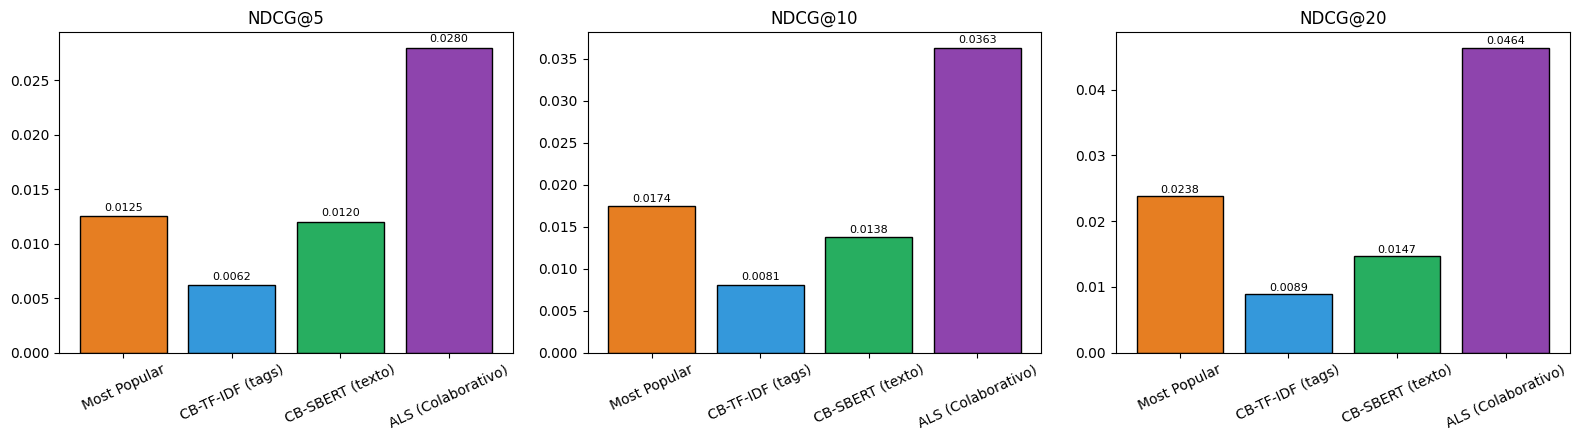

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, k in zip(axes, KS):
    v = results_df[f'NDCG@{k}']
    bars = ax.bar(v.index, v.values, color=['#E67E22','#3498DB','#27AE60','#8E44AD'], edgecolor='black')
    ax.set_title(f'NDCG@{k}'); ax.tick_params(axis='x', rotation=25)
    for b, val in zip(bars, v.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.0005, f'{val:.4f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('ndcg_h2_sbert.png', dpi=120, bbox_inches='tight'); plt.show()

## 9. Desagregación por nivel de actividad del usuario

El feedback pidió entender **cuándo cada modelo aporta valor**. Se agrupan los usuarios
evaluados según cuántas interacciones tienen en train (proxy de cola larga vs. usuarios
activos) y se reporta NDCG@10 por grupo. La hipótesis: el contenido (SBERT) debería
ayudar más a usuarios con poco historial, donde la señal colaborativa es débil.

In [16]:
n_hist = {u: len(train_items_per_user.get(u, set())) for u in eval_users}
def bucket(n):
    if n <= 5:  return '1) 2-5'
    if n <= 10: return '2) 6-10'
    if n <= 20: return '3) 11-20'
    return '4) 21+'
user_bucket = {u: bucket(n_hist[u]) for u in eval_users}

records = []
for name, recs in all_recs.items():
    per_bucket = {}
    for u, rec in recs.items():
        if u not in test_item_per_user: continue
        b = user_bucket[u]
        per_bucket.setdefault(b, []).append(_ndcg(rec, {test_item_per_user[u]}, 10))
    for b, vals in per_bucket.items():
        records.append({'modelo': name, 'grupo': b, 'NDCG@10': np.mean(vals), 'n_users': len(vals)})

disagg = pd.DataFrame(records)
pivot = disagg.pivot(index='grupo', columns='modelo', values='NDCG@10').round(4).sort_index()
counts = disagg.groupby('grupo')['n_users'].first()
pivot['n_users'] = counts
pivot.to_csv('desagregacion_actividad_h2.csv')
print('Usuarios por grupo de actividad (nº interacciones en train):')
pivot

Usuarios por grupo de actividad (nº interacciones en train):


modelo,ALS (Colaborativo),CB-SBERT (texto),CB-TF-IDF (tags),Most Popular,n_users
grupo,,,,,
1) 2-5,0.0479,0.0142,0.0098,0.0189,781
2) 6-10,0.0343,0.0164,0.0063,0.0174,699
3) 11-20,0.0265,0.0141,0.0078,0.0144,352
4) 21+,0.0114,0.0000,0.0077,0.0162,168


In [17]:
# Descargar resultados (Colab)
try:
    from google.colab import files
    for f in ['resultados_h2_sbert.csv', 'desagregacion_actividad_h2.csv', 'ndcg_h2_sbert.png']:
        if os.path.exists(f): files.download(f)
except Exception as e:
    print('Archivos guardados en el entorno:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Notas para el informe H2

- **Pregunta central de esta parte:** ¿el texto semántico (SBERT) supera a los tags
  (TF-IDF) como señal de contenido? Comparar la fila `CB-SBERT` vs `CB-TF-IDF`.
- **Ablación:** volver a correr con `TEXT_MODE = "description"` (celda de config) para
  aislar el aporte de la descripción semántica sobre los tags.
- **Diversidad/novedad:** reportar Coverage/ILD/Novelty además del ranking (lo pidió el feedback).
- **Desagregación:** discutir si SBERT ayuda más en usuarios de poco historial (cola larga).
- Estos cuatro modelos son baselines/contenido; el **modelo avanzado CPGRec+** y **BPR**
  van en sus propios desarrollos y se integran con estos embeddings en el híbrido.